# Calculate freshwater content

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import time
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42585")
client

<Client: 'tcp://127.0.0.1:42585' processes=8 threads=32, memory=123.95 GiB>

### Open daily mean ZARR datasets

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
# only select the upper 8 vertical levels
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).isel(k=slice(0,8)).where(HH_grid.mask_basin==1)

### Calculate FWC

Estimates of liquid Freshwater Content (FWC in meters) are obtained from integrated differences of the measured salinity and a reference salinity (set to 34.8) from the surface to 10 m depth. For the model, I will select the upper 8 vertical levels which extends to 12 m deep.

FWC = $\int_{0}^{10} \frac{S_{\text{ref}} - S(z)}{S_{\text{ref}}} \, dz$

In [8]:
salt_day.Z.values[0:8]

array([ -0.5  ,  -1.57 ,  -2.79 ,  -4.185,  -5.78 ,  -7.595,  -9.66 ,
       -12.01 ], dtype=float32)

In [9]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [10]:
# define reference salinity
salt_ref = 34.8

# pull out grid cell thickness
dz = HH_grid.drF.isel(k=slice(0,8))

In [11]:
salt_da = salt_day.isel(time=200)

In [12]:
fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')

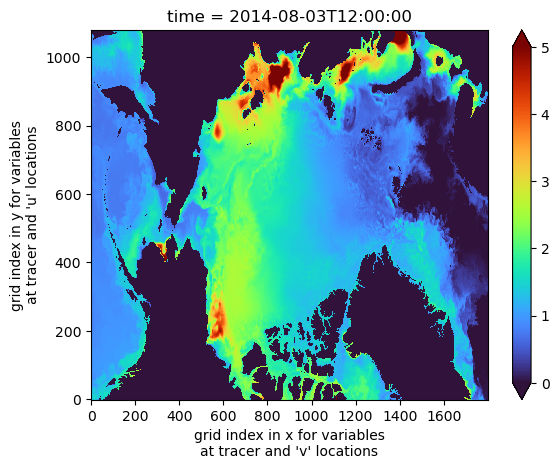

In [13]:
fwc.plot(vmin=0,vmax=5,cmap='turbo');

### Hovmöller Diagram for FWC along E-W Beaufort line

In [14]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0)
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(70,390))
profiles_71N = bathy_beaufort.where((bathy_beaufort.YC >= 71) & (bathy_beaufort.YC < 71.05))

In [15]:
bathy_beaufort_flip = xr.DataArray(np.rot90(bathy_beaufort,3,axes=[0,1]), dims=['i','j'])
HH_land_beaufort_flip = xr.DataArray(np.rot90(HH_land_beaufort,3,axes=[0,1]), dims=['i','j'])
profiles_71N_flip = xr.DataArray(np.rot90(profiles_71N,3,axes=[0,1]), dims=['i','j'])

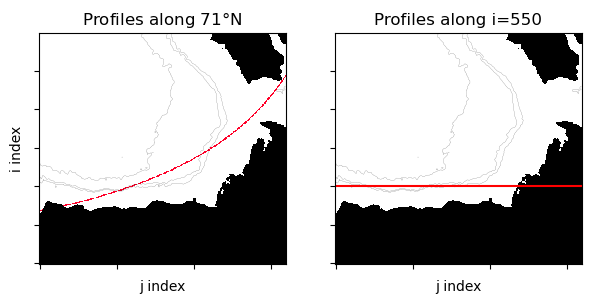

In [16]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[7,3],sharey=True)
profiles_71N_mask = xr.where(profiles_71N_flip.notnull(), 1, np.nan)
profiles_71N_mask.plot(ax=ax1,vmin=0,vmax=0.8,cmap='gist_rainbow_r',add_colorbar=False);
HH_land_beaufort_flip.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort_flip.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

HH_land_beaufort_flip.plot(ax=ax2,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort_flip.plot.contour(ax=ax2, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax2.axhline(y=550-450,c='red')

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax2.set_ylabel('')
ax2.set_xlabel('j index')

# Remove tick labels
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])

ax1.set_title(f'Profiles along 71$\degree$N');
ax2.set_title(f'Profiles along i=550');

In [17]:
sss_sept = salt_day.isel(i=slice(450,750),j=slice(70,390),k=0).sel(time='2020-09-15').isel(time=0)
sss_beaufort_flip = xr.DataArray(np.rot90(sss_sept,3,axes=[0,1]), dims=['i','j'])

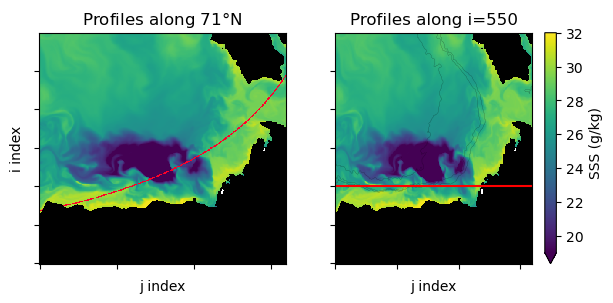

In [18]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[7,3],sharey=True)
sss_beaufort_flip.plot(ax=ax1, vmin=19,vmax=32, cmap='viridis',add_colorbar=False)
sss_beaufort_flip.plot(ax=ax2, vmin=19,vmax=32, cmap='viridis',add_colorbar=True, cbar_kwargs={'label': 'SSS (g/kg)'})

profiles_71N_mask = xr.where(profiles_71N_flip.notnull(), 1, np.nan)
profiles_71N_mask.plot(ax=ax1,vmin=0,vmax=0.8,cmap='gist_rainbow_r',add_colorbar=False);
HH_land_beaufort_flip.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);

HH_land_beaufort_flip.plot(ax=ax2,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort_flip.plot.contour(ax=ax2, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax2.axhline(y=550-450,c='red')

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax2.set_ylabel('')
ax2.set_xlabel('j index')

# Remove tick labels
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])

ax1.set_title(f'Profiles along 71$\degree$N');
ax2.set_title(f'Profiles along i=550');

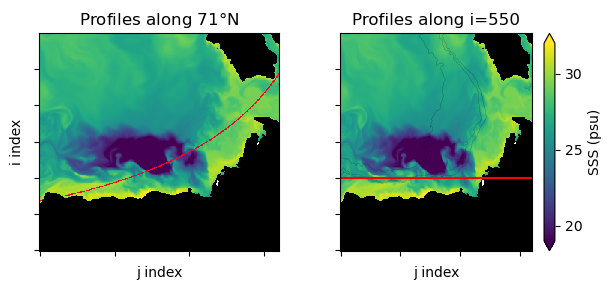

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[6, 3], sharey=True)

# Plot sss_beaufort_flip data
sss_beaufort_plot = sss_beaufort_flip.plot(ax=ax1, vmin=19, vmax=32, cmap='viridis', add_colorbar=False)
cbar = sss_beaufort_flip.plot(ax=ax2, vmin=19, vmax=32, cmap='viridis', add_colorbar=False)

# Plot additional data on ax1 and ax2
profiles_71N_mask = xr.where(profiles_71N_flip.notnull(), 1, np.nan)
profiles_71N_mask.plot(ax=ax1, vmin=0, vmax=0.8, cmap='gist_rainbow_r', add_colorbar=False)
HH_land_beaufort_flip.plot(ax=ax1, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)

HH_land_beaufort_flip.plot(ax=ax2, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)
bathy_beaufort_flip.plot.contour(ax=ax2, colors='k', linewidths=0.1, levels=[500, 1000, 3000])
ax2.axhline(y=550-450, c='red')

# Set labels and titles
ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax2.set_ylabel('')
ax2.set_xlabel('j index')

# Remove tick labels
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax2.set_xticklabels([])
ax2.set_yticklabels([])

ax1.set_title(f'Profiles along 71$\degree$N')
ax2.set_title(f'Profiles along i=550')

fig.subplots_adjust(wspace=0.4)

# Add colorbar
cbar = fig.colorbar(cbar, ax=ax2, orientation='vertical', pad=0.05, extend='both')
cbar.set_label('SSS (psu)')

# Move the colorbar using bbox_to_anchor
cbar.ax.locator_params(nbins=5)  # Optional: Set the number of ticks on the colorbar
cbar.ax.set_position([0.5, 0.1, 0.03, 0.8])

plt.tight_layout()

In [20]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

#### Do a test

In [21]:
salt_select = salt_day.isel(i=550,j=slice(151,390)).sel(time='2019')
dz = HH_grid.isel(i=550,j=slice(151,390)).drF.isel(k=slice(0,8))

In [22]:
fwc_line = calculate_fwc(salt_select, salt_ref, dz)

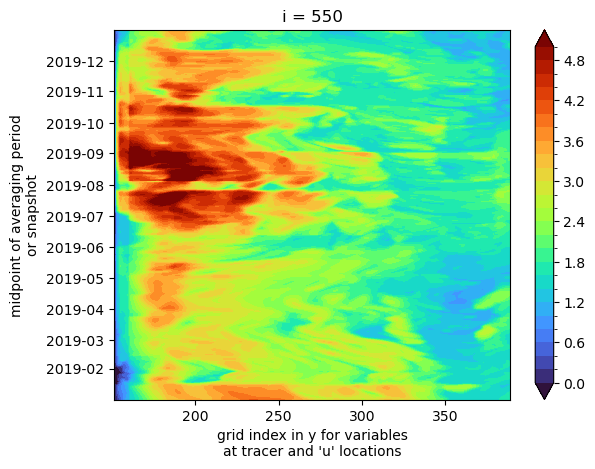

In [23]:
fwc_line.plot.contourf(y='time',levels=np.arange(0,5.2,0.2),cmap='turbo');

#### All years

In [24]:
salt_select = salt_day.isel(i=550,j=slice(151,390))
dz = HH_grid.isel(i=550,j=slice(151,390)).drF.isel(k=slice(0,8))

In [25]:
fwc_line = calculate_fwc(salt_select, salt_ref, dz)

Add sea ice contour

In [26]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [27]:
sic_select = ice_da.isel(i=550,j=slice(151,390))
# Add DOY coordinate to the dataset
sic_select = sic_select.assign_coords(dayofyear=sic_select.time.dt.dayofyear)

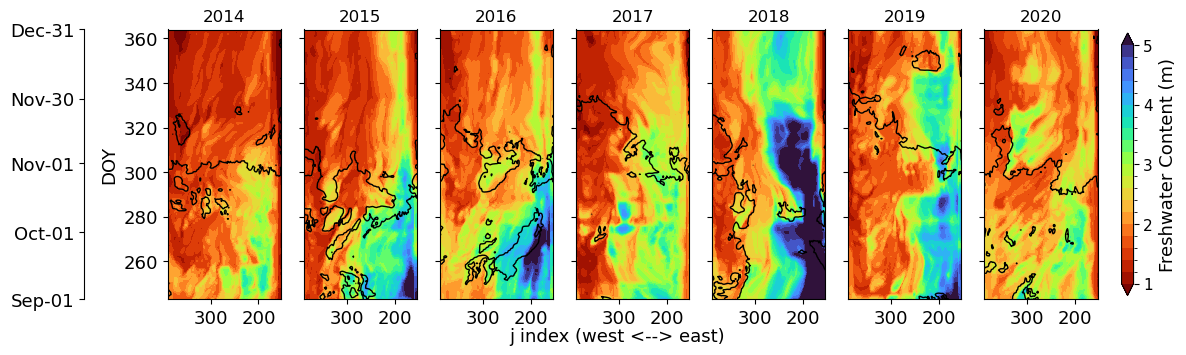

In [31]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = np.arange(1,5.2,0.2)

# Add DOY coordinate to the dataset
fwc_line = fwc_line.assign_coords(dayofyear=fwc_line.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    fwc_year = fwc_line.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = fwc_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap='turbo_r', levels=levels, add_colorbar=False
    )

    # Select data for the given year
    ice_conc_year = sic_select.sel(time=str(year))
    # Plot contour line for 15% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='k', linewidths=1
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("Freshwater Content (m)")
cbar.ax.tick_params(labelsize=11)
cbar.set_ticks([1, 2, 3, 4, 5])

plt.show()

### Plot freshwater content and SSS

In [32]:
SSS_beaufort = salt_day.isel(k=0,i=slice(450,750),j=slice(70,390))

In [33]:
salt_beaufort = salt_day.isel(k=slice(0,8),i=slice(450,750),j=slice(70,390))
dz = HH_grid.isel(i=slice(450,750),j=slice(70,390)).drF.isel(k=slice(0,8))

In [34]:
FWC_beaufort = calculate_fwc(salt_beaufort, salt_ref, dz)

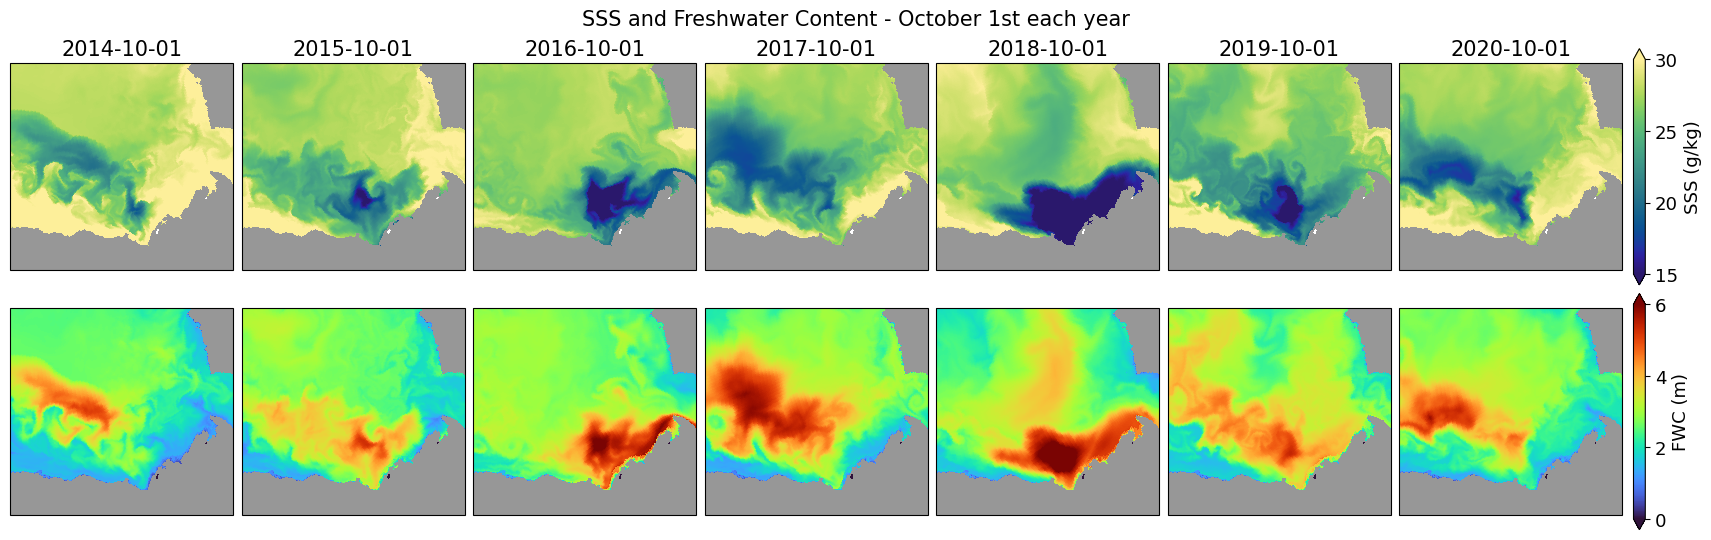

In [48]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(2, 7, figsize=(17, 5), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 15
vmax_SSS = 30
vmin_FWC = 0
vmax_FWC = 6

years = np.arange(2014,2022,1)

# Loop through each year and plot all variables
for i in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap=cmocean.cm.haline, vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.sel(time=str(years[i])+'-10-01').time.values)[2:12],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    FWC_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_FWC, vmax=vmax_FWC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    (cmocean.cm.haline, vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('turbo', vmin_FWC, vmax_FWC, 'FWC (m)'),
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS and Freshwater Content - October 1st each year', fontsize=15, y=1.05);

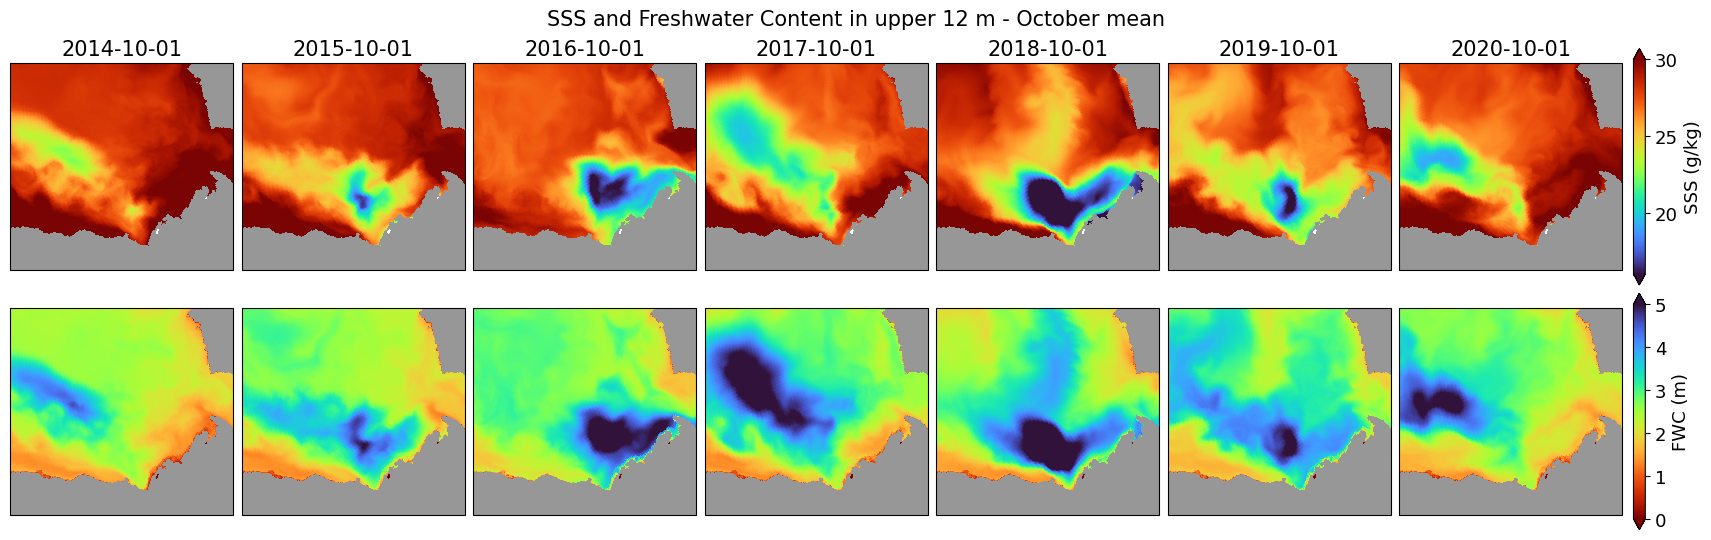

In [49]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(2, 7, figsize=(17, 5), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 16
vmax_SSS = 30
vmin_FWC = 0
vmax_FWC = 5

years = np.arange(2014,2022,1)

# Loop through each year and plot all variables
for i in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.sel(time=str(years[i])+'-10').mean(dim='time').plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.sel(time=str(years[i])+'-10').time.values)[2:12],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    FWC_beaufort.sel(time=str(years[i])+'-10').mean(dim='time').plot(x='XC', y='YC', ax=ax, cmap='turbo_r', vmin=vmin_FWC, vmax=vmax_FWC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    ('turbo', vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('turbo_r', vmin_FWC, vmax_FWC, 'FWC (m)'),
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS and Freshwater Content in upper 12 m - October mean', fontsize=15, y=1.05);

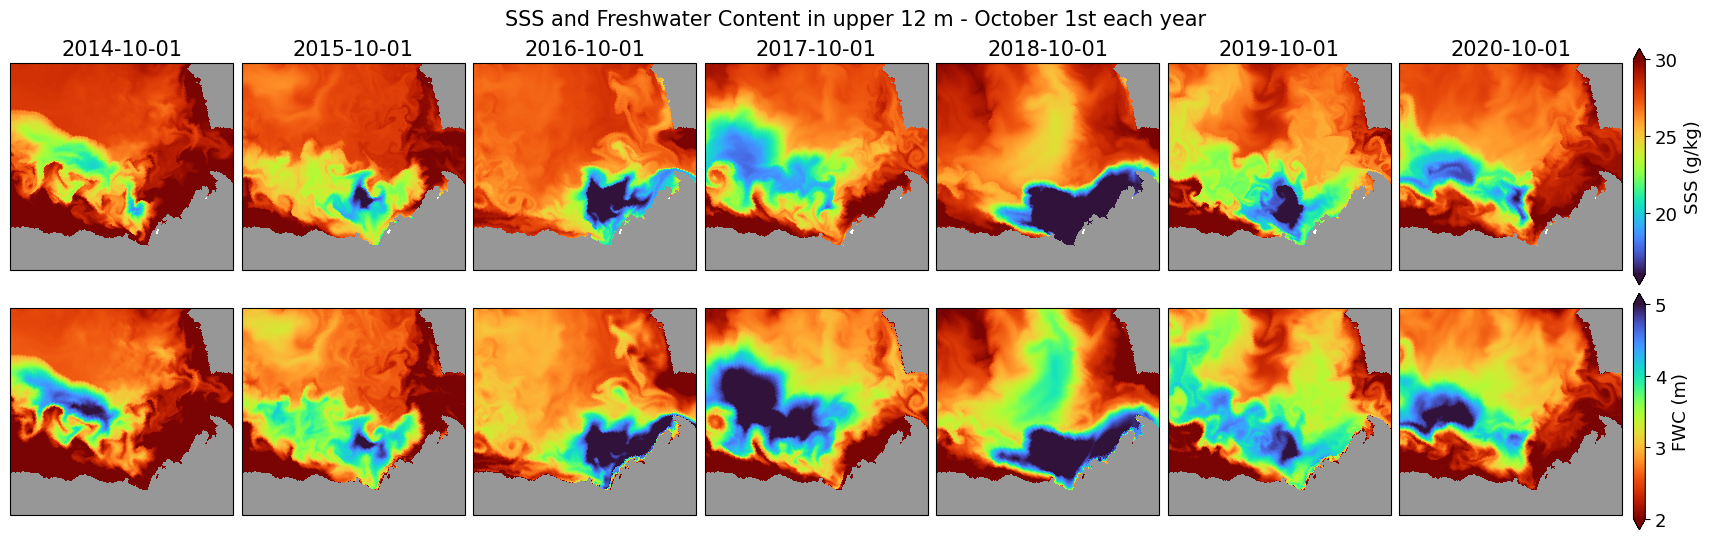

In [50]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(2, 7, figsize=(17, 5), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 16
vmax_SSS = 30
vmin_FWC = 2
vmax_FWC = 5

years = np.arange(2014,2022,1)

# Loop through each year and plot all variables
for i in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.sel(time=str(years[i])+'-10-01').time.values)[2:12],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    FWC_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap='turbo_r', vmin=vmin_FWC, vmax=vmax_FWC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    ('turbo', vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('turbo_r', vmin_FWC, vmax_FWC, 'FWC (m)'),
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS and Freshwater Content in upper 12 m - October 1st each year', fontsize=15, y=1.05);

### FWC in upper 100 m

In [170]:
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).isel(k=slice(0,22)).where(HH_grid.mask_basin==1)

In [171]:
SSS_beaufort = salt_day.isel(k=0,i=slice(450,750),j=slice(70,390))

In [172]:
salt_beaufort = salt_day.where(HH_grid.Depth>150).isel(i=slice(450,750),j=slice(70,390))
dz = HH_grid.isel(i=slice(450,750),j=slice(70,390)).drF.isel(k=slice(0,22))

In [173]:
FWC_beaufort = calculate_fwc(salt_beaufort, salt_ref, dz)

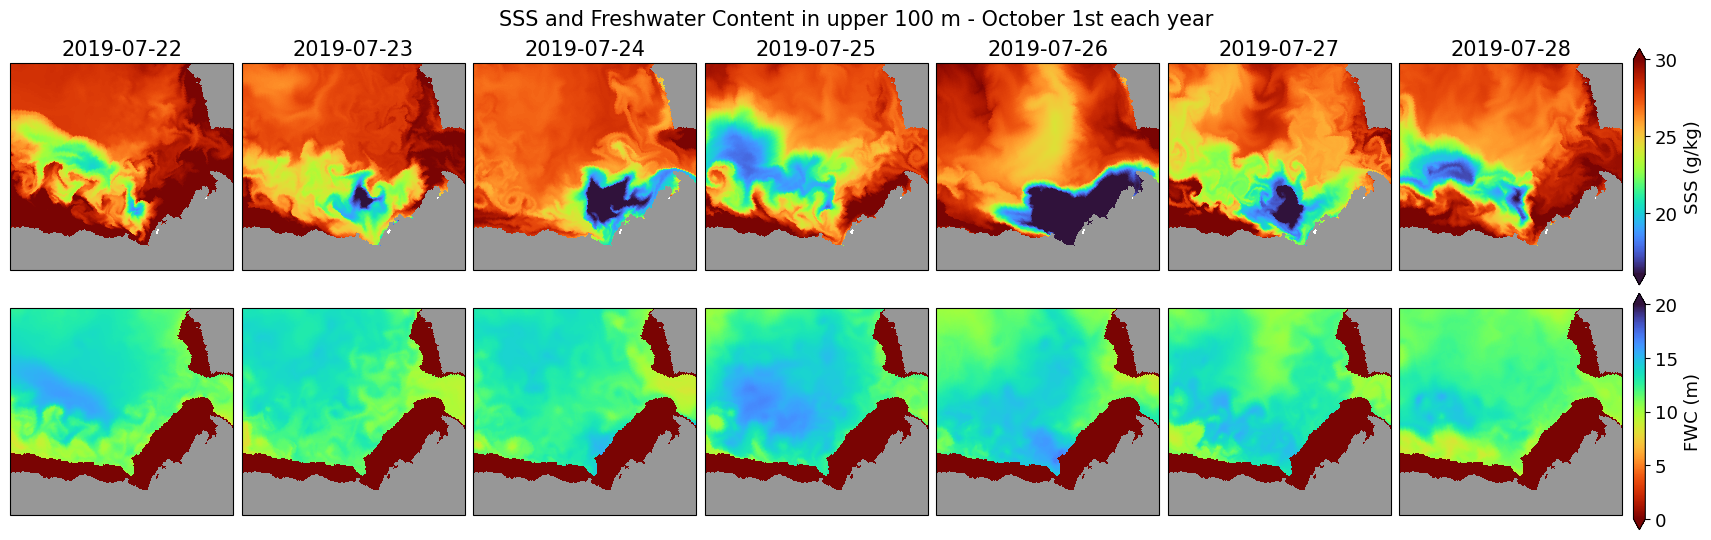

In [174]:
# Set up the figure and subplots (4 rows, 7 columns) with Cartopy
fig, axes = plt.subplots(2, 7, figsize=(17, 5), subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)}, layout='constrained')

# Define the colormap and range for each dataset
vmin_SSS = 16
vmax_SSS = 30
vmin_FWC = 0
vmax_FWC = 20

years = np.arange(2014,2022,1)

# Loop through each year and plot all variables
for i in range(0, 7):
    
    # SSS (Row 1)
    ax = axes[0, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    SSS_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap='turbo', vmin=vmin_SSS, vmax=vmax_SSS, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    # ax.set_title(str(SSS_beaufort.isel(time=year).time.dt.year.values))
    ax.set_title(str(SSS_beaufort.isel(time=years[i]).time.values)[0:10],fontsize=15)
    
    # SST (Row 2)
    ax = axes[1, i]
    ax.set_extent([-150, -128, 69, 75], crs=ccrs.PlateCarree())
    FWC_beaufort.sel(time=str(years[i])+'-10-01').plot(x='XC', y='YC', ax=ax, cmap='turbo_r', vmin=vmin_FWC, vmax=vmax_FWC, transform=ccrs.PlateCarree(), add_colorbar=False)
    HH_grid_land.plot(x='XC', y='YC', ax=ax, cmap='Greys_r', add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title("")
    
# Add colorbars to the last column
colorbars = [
    ('turbo', vmin_SSS, vmax_SSS, 'SSS (g/kg)'),
    ('turbo_r', vmin_FWC, vmax_FWC, 'FWC (m)'),
]

for i, (cmap, vmin, vmax, label) in enumerate(colorbars):
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)), ax=axes[i, -1], location='right',extend='both')
    cbar.ax.set_ylabel(label)

# Set the main title
plt.suptitle('SSS and Freshwater Content in upper 100 m - October 1st each year', fontsize=15, y=1.05);